# Notes for Deep Learning with PyTorch Chapter 07
> "Telling birds from airplanes : Learning from images. Including building a feed-forward neural network; loading data using Datasetss and DataLoaders; understanding classification loss"

- toc: false
- badges: true
- comments: true
- categories: [image recognition, CIFAR-10]
- image: images/dlwpt-screenshots/dlwpt-07-logo.png

## Chapter Contents
- [7.1. a dataset of tiny images](#7.1.)
    - [7.1.1. downloading CIFAR-10](#7.1.1.)
    - [7.1.2. the dataset class](#7.1.2.)
    - [7.1.3. dataset transforms](#7.1.3.)
    - [7.1.4. normalizing data](#7.1.4.)
- [7.2. distinguishing birds from airplanes](#7.2.)
    - [7.2.1. building the dataset](#7.2.1.)
    - [7.2.2. a fully connected model](#7.2.2.)
    - [7.2.3. output of a classifier](#7.2.3.)
    - [7.2.4. representing the output as probabilities](#7.2.4.)
    - [7.2.5. a loss for classifying](#7.2.5.)
    - [7.2.6. training the classifier](#7.2.6.)
    - [7.2.7. the limits of going fully connected](#7.2.7.)
- [7.3. conclusion](#7.3.)
- [7.4. exercise](#7.4.)

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import torch

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

<a id="7.1."></a>
## 7.1. a dataset of tiny images

<a id="7.1.1."></a>
### 7.1.1. a dataset of tiny images

In [2]:
from torchvision import datasets

data_path = 'data' # '../data-unversioned/p1ch7/'
cifar10 = datasets.CIFAR10('data', train=True, download=True)
cifar10_val = datasets.CIFAR10('data', train=False, download=True)

# """
# notes
# 'data'        : file path to where we want to store dataset
# train=True    : get us training data
# train=False   : get us validation data
# download=True : download data if data not present
# """

Files already downloaded and verified
Files already downloaded and verified


### torchvision.datasets

this submodule provides precanned access to:
- [MNIST]() : handwritten digits
- [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) : MNIST for clothes
- [CIFAR-100](https://www.cs.toronto.edu/~kriz/cifar.html) : bigger CIFAR-10; 100 classes containing 600 images
- [SVHN](http://ufldl.stanford.edu/housenumbers/) : like MNIST; street view house numbers
- [Coco](https://cocodataset.org/#home) : Common Objects in COntext; 330K images, 1.5 mil object instances, 80 object categories
- [Omniglot](https://github.com/brendenlake/omniglot) : 50 alphabets fr different languages

in each case, each dataset is returned as subclass of `torch.utils.data.Dataset`

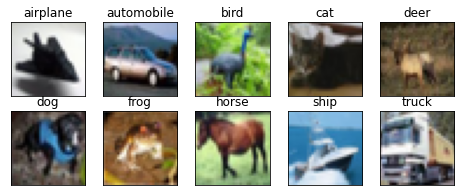

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

fig = plt.figure(figsize=(8,3))
num_classes = 10
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.set_title(class_names[i])
    img = next(img for img, label in cifar10 if label == i)
    plt.imshow(img)
plt.show()

In [4]:
type(cifar10)

torchvision.datasets.cifar.CIFAR10

#### CIFAR-10

- simple dataset that has been computer vision classic for a decade
- nowadays considered too simple for new research

sppecifics
- consists of 60k tiny 32x32 RGB images
- labelled with integers corresponding to 1 of 10 classes:
    - 0. airplane
    - 1. automobile
    - 2. bird
    - 3. cat
    - 4. deer
    - 5. dog
    - 6. frog
    - 7. horse
    - 8. ship
    - 9. truck

<a id="7.1.2."></a>
### 7.1.2. the dataset class

![](../images/dlwpt-screenshots/dlwpt-07-02.png)

In [5]:
isinstance(cifar10, torch.utils.data.Dataset)

# check that the cifar10 dataset object is an instance of torch.utils.data.Dataset

True

In [6]:
len(cifar10)

# number of records in the dataset

50000

In [7]:
img, label = cifar10[99]
img, label, class_names[label]

(<PIL.Image.Image image mode=RGB size=32x32 at 0x7F3BB79BB220>,
 1,
 'automobile')

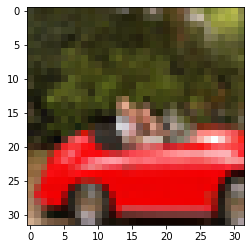

In [8]:
plt.imshow(img)
plt.show()

<a id="7.1.3."></a>
### 7.1.2. dataset transforms

we need to convert the PIL image to a PyTorch tensor. 

In [9]:
from torchvision import transforms
dir(transforms)

# following are composable function-like objects
# passed as argument to the torchvision dataset

['CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandomAffine',
 'RandomApply',
 'RandomChoice',
 'RandomCrop',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomOrder',
 'RandomPerspective',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSizedCrop',
 'RandomVerticalFlip',
 'Resize',
 'Scale',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'functional',
 'functional_pil',
 'functional_tensor',
 'transforms']

note that there is `ToTensor` in the list above

In [10]:
from torchvision import transforms

to_tensor = transforms.ToTensor()

img, label = cifar10[99]

img_t = to_tensor(img)

img_t.shape

torch.Size([3, 32, 32])

In [11]:
cifar10 = datasets.CIFAR10('data', train=True, download=False,
                          transform=transforms.ToTensor())

# we passed the ToTensor transform object to the dataset

In [12]:
img, _ = cifar10[99]
type(img)

# and as expected, the dataset now returns a tensor when we access an element

torch.Tensor

In [13]:
img.shape

torch.Size([3, 32, 32])

In [14]:
img.dtype

torch.float32

In [15]:
img.min(), img.max()

# 255, 255, 255 -> 1.0, 1.0, 1.0

(tensor(0.), tensor(1.))

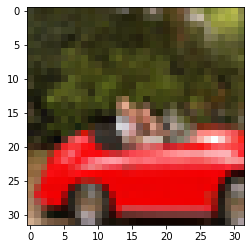

In [16]:
plt.imshow(img.permute(1, 2, 0))
plt.show()

# change the axes from CxHxW to HxWxC

<a id="7.1.4."></a>
### 7.1.4. normalizing data

we can chain transforms using `transforms.Compose`

#### More about normalizing
it’s good practice to normalize the dataset so that each channel has zero mean and unitary standard deviation. We mentioned this in chapter 4, but now, after going through chapter 5, we also have an intuition for why: by choosing activation functions that are linear around 0 plus or minus 1 (or 2), keeping the data in the same range means it’s more likely that neurons have nonzero gradients and hence, will learn sooner. Also, normalizing each channel so that it has the same distribution will ensure that channel information can be mixed and updated through gradient descent using the same learning rate.

In [17]:
imgs = torch.stack([img for img, _ in cifar10], dim=3)
imgs.shape

# stacking allows us to process all the images as a batch
# since images already have dimensions 0, 1, 2
# we need to insert a 3rd dimension

# stack(image1, image2, image3, ... image50000)

torch.Size([3, 32, 32, 50000])

In [18]:
help(torch.stack)

Help on built-in function stack:

stack(...)
    stack(tensors, dim=0, *, out=None) -> Tensor
    
    Concatenates a sequence of tensors along a new dimension.
    
    All tensors need to be of the same size.
    
    Arguments:
        tensors (sequence of Tensors): sequence of tensors to concatenate
        dim (int): dimension to insert. Has to be between 0 and the number
            of dimensions of concatenated tensors (inclusive)
    
    Keyword args:
        out (Tensor, optional): the output tensor.



In [19]:
imgs.view(3, -1).mean(dim=1)

tensor([0.4914, 0.4822, 0.4465])

[more info about -1 in the view function](https://stackoverflow.com/questions/50792316/what-does-1-mean-in-pytorch-view)

Recall that view(3, -1) keeps the three channels and merges all the remaining dimensions into one, figuring out the appropriate size. Here our 3 × 32 × 32 image is transformed into a 3 × 1,024 vector, and then the mean is taken over the 1,024 elements of each channel.

In [20]:
imgs.view(3, -1).std(dim=1)

# standard deviation

tensor([0.2470, 0.2435, 0.2616])

In [21]:
transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616))

# normalize takes in the mean and std as arguments

Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))

In [22]:
cifar10 = datasets.CIFAR10('data', train=True, download=False,
                          transform=transforms.Compose([
                              transforms.ToTensor(),
                              transforms.Normalize((0.4915, 0.4823, 0.4468),
                                                   (0.2470, 0.2435, 0.2616))
                          ]))

In [23]:
cifar10_val = datasets.CIFAR10('data', train=False, download=False,
                          transform=transforms.Compose([
                              transforms.ToTensor(),
                              transforms.Normalize((0.4915, 0.4823, 0.4468),
                                                   (0.2470, 0.2435, 0.2616))
                          ]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


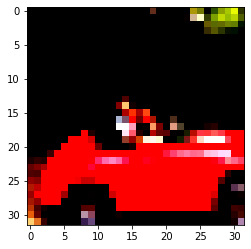

In [24]:
img, _ = cifar10[99]

plt.imshow(img.permute(1, 2, 0))
plt.show()

The renormalized red car we get is shown in figure 7.5. This is because normalization
has shifted the RGB levels outside the 0.0 to 1.0 range and changed the overall magni-
tudes of the channels. All of the data is still there; it’s just that Matplotlib renders it as black. We’ll keep this in mind for the future.

<a id="7.2."></a>
### 7.2. distinguishing birds from airplanes

<a id="7.2.1."></a>
### 7.2.1. building the dataset

In [25]:
label_map = {0: 0, 2: 1}
cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]]

# if label in [0, 2], where 0 is airplane, 2 is bird

In [26]:
3*32*32

3072

In [27]:
import torch.nn as nn

model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2))

# 512 is the hidden layer size

In [28]:
2**9

512

<a id="7.2.2."></a>
### 7.2.2. a fully connected model

![](../images/dlwpt-screenshots/dlwpt-07-07.png)

<a id="7.2.3."></a>
### 7.2.3. output of a classifier

We need to recognize that the output is categorical: it’s either a bird or an air-
plane (or something else if we had all 10 of the original classes). As we learned in
chapter 4, when we have to represent a categorical variable, we should switch to a
one-hot-encoding representation of that variable, such as [1, 0] for airplane or [0, 1]for bird (the order is arbitrary). This will still work if we have 10 classes, as in the full
CIFAR-10 dataset; we’ll just have a vector of length 10. 6
In the ideal case, the network would output torch.tensor([1.0, 0.0]) for an air-
plane and torch.tensor([0.0, 1.0]) for a bird. Practically speaking, since our clas-
sifier will not be perfect, we can expect the network to output something in between.
The key realization in this case is that we can interpret our output as probabilities: the
first entry is the probability of “airplane,” and the second is the probability of “bird.”
Casting the problem in terms of probabilities imposes a few extra constraints on
the outputs of our network:
- Each element of the output must be in the [0.0, 1.0] range (a probability of
an outcome cannot be less than 0 or greater than 1).
- The elements of the output must add up to 1.0 (we’re certain that one of the
two outcomes will occur).

It sounds like a tough constraint to enforce in a differentiable way on a vector of numbers. Yet there’s a very smart trick that does exactly that, and it’s differentiable: it’s called softmax.

<a id="7.2.4."></a>
### 7.2.4. representing the output as possibilities

In [29]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

# what is softmax? see https://www.youtube.com/watch?v=lvNdl7yg4Pg

![](../images/dlwpt-screenshots/dlwpt-07-softmax.jpg)

In [30]:
x = torch.tensor([1.0, 2.0, 3.0])

softmax(x)

tensor([0.0900, 0.2447, 0.6652])

In [31]:
softmax(x).sum()

tensor(1.)

In [32]:
import torch
import torch.nn as nn

torch.manual_seed(123)

softmax = nn.Softmax(dim=1)

x = torch.tensor([[1.0, 2.0, 3.0],
                  [1.0, 2.0, 3.0]])

softmax(x)

tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])

In [33]:
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.Softmax(dim=1))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


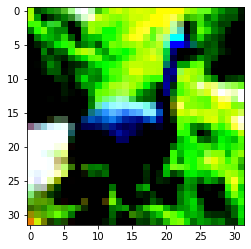

In [34]:
img, _ = cifar2[0]

plt.imshow(img.permute(1, 2, 0))
plt.show()

In [35]:
img_batch = img.view(-1).unsqueeze(0)

In [36]:
out = model(img_batch)
out

tensor([[0.3700, 0.6300]], grad_fn=<SoftmaxBackward>)

- as we said before, in the ideal case, the network would output torch.tensor([1.0, 0.0]) for an airplane and torch.tensor([0.0, 1.0]) for a bird
- however, the value we got here is entirely different from the book
- this is because the weights and biases of our linear layers have not been trained at all. Their elements are initialized randomly by PyTorch between –1.0 and 1.0
- the grad_fn is the tip of the backward computation graph, which we will use soon

In [37]:
_, index = torch.max(out, dim=1)

index

tensor([1])

- we note that the 2nd value (counting from index 0) is the higer value, which means the model recognizes the image as a bird, but this is only because of pure luck, same as what happened in the book

<a id="7.2.5"></a>
## 7.2.5 a loss for classifying

### why can't we just use MSE?
- in actual fact, we could, but to what end?
- ultimately, it means we'll be trying to train our model to converge towards the values of \[0.0, 1.0\] for birds, and \[1.0, 0.0\] for planes, which is unnecessary
- what we're interested in, is for their relative values
    - first probability > second probability when image is a plane
    - first probability < second probability when image is a bird
- we just want to penalize misclassifications, and not waste more effort trying to drive the probabilities down to 0 or up to 1
- we want a loss function that is high when the likelihood is low, and low when the likelihood is high

#### Negative Log Likelihood (NLL)
expression NLL = -sum(log(out_i[c_i])) where:
- sum is taken over N samples
- c_i is the correct class for sample i

![](../images/dlwpt-screenshots/dlwpt-07-10.png)

### Steps for obtaining classification loss
1. Run the forward pass, and obtain the output values from the last (linear) layer.
1. Compute their softmax, and obtain probabilities.
1. Take the predicted probability corresponding to the correct class (the likelihood of the parameters). Note that we know what the correct class is because it’s a supervised problem — it’s our ground truth.
1. Compute its logarithm, slap a minus sign in front of it, and add it to the loss

### Should we use `nn.NLLLoss` class?
- nope, because this class does not take probabilities, but...
- takes tensor of log probabilities as input

In [38]:
softmax = nn.Softmax(dim=1)

log_softmax = nn.LogSoftmax(dim=1)

x = torch.tensor([[0.0, 104.0]])

softmax(x)

tensor([[0., 1.]])

In [39]:
torch.log(softmax(x))

tensor([[-inf, 0.]])

- this is because taking the logarithm of a probability is tricky when probabiliy approaches zero as you can see above

In [40]:
log_softmax(x)

tensor([[-104.,    0.]])

In [41]:
torch.exp(log_softmax(x))

tensor([[0., 1.]])

- solution: use `nn.LogSoftmax` instead of `nn.Softmax` as the output module to prevent the mentioned problem!

### Let's try out `nn.LogSoftmax` in our model

In [42]:
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

In [43]:
loss = nn.NLLLoss()

In [44]:
img, label = cifar2[0]

out = model(img.view(-1).unsqueeze(0))

loss(out, torch.tensor([label]))

tensor(0.6509, grad_fn=<NllLossBackward>)

### Let's check out the classification losses

- for cross-entropy loss: when the prediction is off target (in the low-loss corner, the correct class is assigned a predicted probability of 99.97%), 
- for the MSE (which we dismissed at the beginning): saturates much earlier and—crucially—also for very wrong predictions. 
- underlying reason is that the slope of the MSE is too low to compensate for the flatness of the soft-max function for wrong predictions. 
- This is why the MSE for probabilities is not a good fit for classification work.

![](../images/dlwpt-screenshots/dlwpt-07-11.png)

<a id="7.2.6"></a>
## 7.2.6. Training the classifier

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for img, label in cifar2:
        out = model(img.view(-1).unsqueeze(0))
        loss = loss_fn(out, torch.tensor([label]))
                
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))
    # Prints the loss for the last image. In the next chapter, 
    # we will improve our output to give an average over bthe entire epoch.

Epoch: 0, Loss: 5.456484
Epoch: 1, Loss: 6.948841


KeyboardInterrupt: 

![](../images/dlwpt-screenshots/dlwpt-07-12.png)

### Minibatches

![](../images/dlwpt-screenshots/dlwpt-07-13.png)

![](../images/dlwpt-screenshots/dlwpt-07-14.png)

In [61]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.LogSoftmax(dim=1))

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.463565
Epoch: 1, Loss: 0.500854
Epoch: 2, Loss: 0.375690
Epoch: 3, Loss: 0.497873
Epoch: 4, Loss: 0.420752
Epoch: 5, Loss: 0.443394
Epoch: 6, Loss: 0.453353
Epoch: 7, Loss: 0.349348
Epoch: 8, Loss: 0.346864
Epoch: 9, Loss: 0.354345
Epoch: 10, Loss: 0.448821
Epoch: 11, Loss: 0.185538
Epoch: 12, Loss: 0.268360
Epoch: 13, Loss: 0.278273
Epoch: 14, Loss: 0.256954
Epoch: 15, Loss: 0.312784
Epoch: 16, Loss: 0.159850
Epoch: 17, Loss: 0.161434
Epoch: 18, Loss: 0.384862
Epoch: 19, Loss: 0.190393
Epoch: 20, Loss: 0.215347
Epoch: 21, Loss: 0.387309
Epoch: 22, Loss: 0.125178
Epoch: 23, Loss: 0.214828
Epoch: 24, Loss: 0.074941
Epoch: 25, Loss: 0.214274
Epoch: 26, Loss: 0.125597
Epoch: 27, Loss: 0.253085
Epoch: 28, Loss: 0.202976
Epoch: 29, Loss: 0.559012
Epoch: 30, Loss: 0.070992
Epoch: 31, Loss: 0.197981
Epoch: 32, Loss: 0.161889
Epoch: 33, Loss: 0.121571
Epoch: 34, Loss: 0.104409
Epoch: 35, Loss: 0.178358
Epoch: 36, Loss: 0.305767
Epoch: 37, Loss: 0.147422
Epoch: 38, Loss: 0.222

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.463648
Epoch: 1, Loss: 0.407758
Epoch: 2, Loss: 0.196614
Epoch: 3, Loss: 0.285308
Epoch: 4, Loss: 0.358289
Epoch: 5, Loss: 0.388683
Epoch: 6, Loss: 0.418425
Epoch: 7, Loss: 0.363164
Epoch: 8, Loss: 0.320129
Epoch: 9, Loss: 0.331565
Epoch: 10, Loss: 0.258742
Epoch: 11, Loss: 0.379268
Epoch: 12, Loss: 0.351960
Epoch: 13, Loss: 0.322769
Epoch: 14, Loss: 0.329542
Epoch: 15, Loss: 0.515023
Epoch: 16, Loss: 0.239433
Epoch: 17, Loss: 0.361607
Epoch: 18, Loss: 0.306934
Epoch: 19, Loss: 0.647506
Epoch: 20, Loss: 0.285462
Epoch: 21, Loss: 0.154191
Epoch: 22, Loss: 0.229041
Epoch: 23, Loss: 0.304382
Epoch: 24, Loss: 0.296479
Epoch: 25, Loss: 0.145210
Epoch: 26, Loss: 0.142413
Epoch: 27, Loss: 0.211748
Epoch: 28, Loss: 0.195603
Epoch: 29, Loss: 0.281106
Epoch: 30, Loss: 0.138811
Epoch: 31, Loss: 0.214966
Epoch: 32, Loss: 0.132533
Epoch: 33, Loss: 0.169920
Epoch: 34, Loss: 0.135977
Epoch: 35, Loss: 0.110315
Epoch: 36, Loss: 0.048091
Epoch: 37, Loss: 0.233725
Epoch: 38, Loss: 0.080

In [64]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.999700


In [65]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.817500


#### Adding more layers to the model (arbitrarily)

In [66]:
model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.LogSoftmax(dim=1))

In [67]:
model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

loss_fn = nn.CrossEntropyLoss()

In [68]:
import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.548016
Epoch: 1, Loss: 0.646204
Epoch: 2, Loss: 0.297184
Epoch: 3, Loss: 0.252828
Epoch: 4, Loss: 0.374628
Epoch: 5, Loss: 0.576822
Epoch: 6, Loss: 1.000422
Epoch: 7, Loss: 0.385794
Epoch: 8, Loss: 0.458561
Epoch: 9, Loss: 0.517302
Epoch: 10, Loss: 0.565785
Epoch: 11, Loss: 0.381962
Epoch: 12, Loss: 0.339050
Epoch: 13, Loss: 0.332571
Epoch: 14, Loss: 0.372688
Epoch: 15, Loss: 0.340013
Epoch: 16, Loss: 0.271055
Epoch: 17, Loss: 0.372709
Epoch: 18, Loss: 0.341391
Epoch: 19, Loss: 0.216403
Epoch: 20, Loss: 0.551033
Epoch: 21, Loss: 0.256305
Epoch: 22, Loss: 0.263578
Epoch: 23, Loss: 0.633184
Epoch: 24, Loss: 0.283749
Epoch: 25, Loss: 0.385304
Epoch: 26, Loss: 0.745120
Epoch: 27, Loss: 0.276860
Epoch: 28, Loss: 0.249441
Epoch: 29, Loss: 0.396805
Epoch: 30, Loss: 0.077044
Epoch: 31, Loss: 0.207166
Epoch: 32, Loss: 0.206418
Epoch: 33, Loss: 0.258428
Epoch: 34, Loss: 0.153729
Epoch: 35, Loss: 0.049702
Epoch: 36, Loss: 0.153448
Epoch: 37, Loss: 0.176399
Epoch: 38, Loss: 0.010

In [69]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 1.000000


In [70]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.810500


#### Determining how many parameters a model has

In [71]:
sum([p.numel() for p in model.parameters()])

3737474

In [72]:
sum([p.numel() for p in model.parameters() if p.requires_grad == True])

3737474

In [73]:
first_model = nn.Sequential(
                nn.Linear(3072, 512),
                nn.Tanh(),
                nn.Linear(512, 2),
                nn.LogSoftmax(dim=1))

sum([p.numel() for p in first_model.parameters()])

1574402

In [74]:
sum([p.numel() for p in nn.Linear(3072, 512).parameters()])

1573376

In [75]:
sum([p.numel() for p in nn.Linear(3072, 1024).parameters()])

3146752

In [76]:
linear = nn.Linear(3072, 1024)

linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))

<a id="7.2.7."></a>
## 7.2.7. The limits of going fully connected

![](../images/dlwpt-screenshots/dlwpt-07-14.png)

![](../images/dlwpt-screenshots/dlwpt-07-15.png)

![](../images/dlwpt-screenshots/dlwpt-07-16.png)

<a id="7.3."></a>
## 7.3. Conclusion

In this chapter, we have solved a simple classification problem from dataset, to model,
to minimizing an appropriate loss in a training loop. All of these things will be stan-
dard tools for your PyTorch toolbelt, and the skills needed to use them will be useful
throughout your PyTorch tenure.
We’ve also found a severe shortcoming of our model: we have been treating 2D
images as 1D data. Also, we do not have a natural way to incorporate the translation
invariance of our problem. In the next chapter, you’ll learn how to exploit the 2D
nature of image data to get much better results. 9
We could use what we have learned right away to process data without this translation
invariance. For example, using it on tabular data or the time-series data we met in chap-
ter 4, we can probably do great things already. To some extent, it would also be possible
to use it on text data that is appropriately represented.

<a id="7.4."></a>
## 7.4. Exercise

1. Use torchvision to implement random cropping of the data.
    1. How are the resulting images different from the uncropped originals?
    1. What happens when you request the same image a second time?
    1. What is the result of training using randomly cropped images?
1. Switch loss functions (perhaps MSE).
    1. Does the training behavior change?  -- will it overfit easily?
1. Is it possible to reduce the capacity of the network enough that it stops overfitting?
    1. How does the model perform on the validation set when doing so?

In [55]:
from torchvision.transforms import RandomResizedCrop
from PIL import Image

img = Image.open("../data/dlwpt/bobby.jpg")

size = 224
rcrop = RandomResizedCrop(size, scale=(0.08, 1.0), ratio=(0.75, 1.3333333333333333)) 4/3
#RandomResizedCrop(size, scale=(0.08, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=<InterpolationMode.BILINEAR: 'bilinear'>)
img_1 = rcrop(img)
img_2 = rcrop(img)
img_3 = rcrop(img)

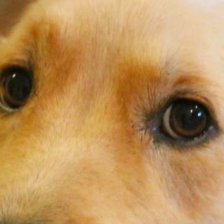

In [59]:
img_1

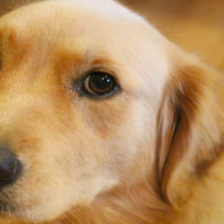

In [57]:
img_2

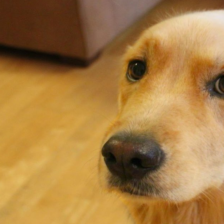

In [58]:
img_3